# 02 Exploratory Data Analysis

This notebook continues after the initial data quality checks completed in `01_data_quality_check.ipynb`.

The previous notebook confirmed that all datasets were loaded correctly, had no missing values, contained no duplicated rows, and had date columns converted successfully.

In this notebook, the same datasets are loaded again so we can begin exploratory data analysis, identify patterns, compare metrics, and generate early insights across financials, drug approvals, clinical trials, disease burden, and biotech funding.

## Step 16: Prepare Datasets for Exploratory Analysis

The initial data quality checks were completed in `01_data_quality_check.ipynb`.

In this step, the required libraries are imported again, all datasets are loaded, and date columns are converted to datetime format so that this notebook can run independently.

In [1]:
# Import core libraries
# Reference: 01_data_quality_check.ipynb - Step 1
import pandas as pd
import numpy as np

# Set display options for easier inspection of wide tables
# Reference: 01_data_quality_check.ipynb - Step 1
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

# Load all project datasets
# Reference: 01_data_quality_check.ipynb - Step 3
clinical_trials = pd.read_csv("clinical_trials.csv")
disease_burden = pd.read_csv("disease_burden.csv")
biotech_funding = pd.read_csv("biotech_funding.csv")
drug_approvals = pd.read_csv("drug_approvals.csv")
pharma_financials = pd.read_csv("pharma_companies_financials.csv")

# Convert date columns to datetime format for time-based analysis
# Reference: 01_data_quality_check.ipynb - Step 13 and Step 14
clinical_trials["completion_date"] = pd.to_datetime(clinical_trials["completion_date"])
biotech_funding["date"] = pd.to_datetime(biotech_funding["date"])
drug_approvals["approval_date"] = pd.to_datetime(drug_approvals["approval_date"])

## Step 17: Summary Statistics for Clinical Trials

This step provides summary statistics for the numerical columns in the clinical trials dataset. It helps us understand the range, average values, and possible outliers in enrollment size, trial duration, success indicators, and estimated stock impact.

In [2]:
clinical_trials.describe()

,completion_date,year,enrollment_n,duration_months,is_success,is_failure,estimated_stock_impact_pct
count,599,599.000000,599.000000,599.000000,599.000000,599.000000,599.000000
mean,2018-02-06 13:10:55.091819776,2017.612688,790.163606,27.555927,0.520868,0.325543,-0.961436
min,2010-01-05 00:00:00,2010.000000,47.000000,6.000000,0.000000,0.000000,-41.200000
25%,2013-10-04 12:00:00,2013.000000,244.500000,18.000000,0.000000,0.000000,-8.550000
50%,2018-02-12 00:00:00,2018.000000,524.000000,29.000000,1.000000,0.000000,1.200000
75%,2022-05-25 00:00:00,2022.000000,1112.000000,36.000000,1.000000,1.000000,8.200000
max,2026-04-05 00:00:00,2026.000000,4179.000000,56.000000,1.000000,1.000000,21.600000
std,NaN,4.759807,720.689342,10.885531,0.499982,0.468969,12.063116


## Step 18: Summary Statistics for Disease Burden

This step provides summary statistics for the numerical columns in the disease burden dataset. It helps us understand the range and distribution of regional and global DALY values across diseases, regions, and years.

In [3]:
disease_burden.describe()

,year,dalys_millions,global_dalys_millions
count,3310.000000,3310.000000,3310.000000
mean,2018.108761,11.068704,108.925982
std,4.902212,13.754323,95.351576
min,2010.000000,0.100000,0.000000
25%,2014.000000,2.640000,43.000000
50%,2018.000000,6.280000,73.500000
75%,2022.000000,13.907500,149.000000
max,2026.000000,98.500000,430.000000


## Step 19: Summary Statistics for Biotech Funding

This step provides summary statistics for the numerical columns in the biotech funding dataset. It helps us understand the scale of deal values, the distribution of megadeals, and the share of verified headline records.

In [4]:
biotech_funding.describe()

,date,year,value_usd_bn,is_megadeal,is_real_headline
count,1208,1208.000000,1208.000000,1208.000000,1208.000000
mean,2019-02-22 21:58:24.635761664,2018.653974,1.614002,0.039735,0.022351
min,2009-03-09 00:00:00,2009.000000,0.005000,0.000000,0.000000
25%,2015-09-30 00:00:00,2015.000000,0.095000,0.000000,0.000000
50%,2019-10-28 12:00:00,2019.000000,0.208000,0.000000,0.000000
75%,2022-07-31 12:00:00,2022.000000,0.486250,0.000000,0.000000
max,2026-04-17 00:00:00,2026.000000,74.000000,1.000000,1.000000
std,NaN,4.281844,6.730375,0.195417,0.147884


## Step 20: Summary Statistics for Drug Approvals

This step provides summary statistics for the numerical columns in the drug approvals dataset. It helps us understand approval years, estimated peak sales, blockbuster shares, mega-blockbuster shares, and the share of verified headline records.

In [5]:
drug_approvals.describe()

,approval_date,year,peak_sales_usd_bn_est,is_blockbuster,is_mega_blockbuster,is_real_headline
count,722,722.000000,722.000000,722.000000,722.000000,722.000000
mean,2018-11-23 08:28:35.235457024,2018.400277,1.173850,0.211911,0.058172,0.060942
min,2010-01-27 00:00:00,2010.000000,0.010000,0.000000,0.000000,0.000000
25%,2015-03-17 06:00:00,2015.000000,0.070000,0.000000,0.000000,0.000000
50%,2019-03-07 12:00:00,2019.000000,0.230000,0.000000,0.000000,0.000000
75%,2022-11-06 18:00:00,2022.000000,0.767500,0.000000,0.000000,0.000000
max,2026-04-21 00:00:00,2026.000000,37.000000,1.000000,1.000000,1.000000
std,NaN,4.442782,3.130775,0.408946,0.234230,0.239389


## Step 21: Summary Statistics for Pharma Financials

This step provides summary statistics for the numerical columns in the pharma financials dataset. It helps us understand the range of company revenues, operating margins, R&D spending, operating income, and estimated pipeline size.

In [6]:
pharma_financials.describe()

,year,revenue_usd_bn,operating_margin_pct,operating_income_usd_bn,rd_spend_usd_bn,pipeline_size_est
count,489.000000,489.000000,489.000000,489.000000,489.000000,489.000000
mean,2018.220859,28.596769,25.432515,7.345603,4.703190,59.036810
std,4.864169,20.254987,8.102994,5.557236,3.382745,36.943226
min,2010.000000,0.060000,-12.700000,-0.710000,0.020000,3.000000
25%,2014.000000,13.770000,22.100000,3.090000,1.880000,19.000000
50%,2018.000000,24.160000,27.200000,6.170000,4.080000,69.000000
75%,2022.000000,43.160000,30.100000,10.710000,7.050000,92.000000
max,2026.000000,98.000000,45.500000,37.040000,17.590000,128.000000


## Initial Summary Statistics Insights

The first round of summary statistics shows that the datasets cover the expected 2010–2026 period, with one biotech funding record starting in 2009.

Several numerical variables show strong differences between mean and median values. This suggests skewed distributions, especially in biotech funding deal values, estimated drug peak sales, disease burden, and company financial performance.

Early observations:

- Clinical trials show an average success indicator of approximately 52%.
- Disease burden values vary widely across diseases and regions.
- Biotech funding is highly skewed, with a small number of very large deals.
- Drug approval peak sales estimates are also skewed, suggesting blockbuster concentration.
- Pharma companies differ significantly in revenue scale, R&D spending, operating margin, and pipeline size.

These patterns suggest that later analysis should focus not only on averages, but also on concentration, outliers, therapy area differences, company-level differences, and innovation efficiency.

## Step 23: Check Time Coverage Across Datasets

This step checks the minimum year, maximum year, and number of unique years in each dataset. This helps confirm the time coverage of the project and identify whether all datasets cover the same period.

In [7]:
time_coverage = pd.DataFrame({
    "dataset": [
        "clinical_trials",
        "disease_burden",
        "biotech_funding",
        "drug_approvals",
        "pharma_financials"
    ],
    "min_year": [
        clinical_trials["year"].min(),
        disease_burden["year"].min(),
        biotech_funding["year"].min(),
        drug_approvals["year"].min(),
        pharma_financials["year"].min()
    ],
    "max_year": [
        clinical_trials["year"].max(),
        disease_burden["year"].max(),
        biotech_funding["year"].max(),
        drug_approvals["year"].max(),
        pharma_financials["year"].max()
    ],
    "unique_years": [
        clinical_trials["year"].nunique(),
        disease_burden["year"].nunique(),
        biotech_funding["year"].nunique(),
        drug_approvals["year"].nunique(),
        pharma_financials["year"].nunique()
    ]
})

time_coverage

,dataset,min_year,max_year,unique_years
0,clinical_trials,2010,2026,17
1,disease_burden,2010,2026,17
2,biotech_funding,2009,2026,18
3,drug_approvals,2010,2026,17
4,pharma_financials,2010,2026,17


### Time Coverage Observation

Most datasets cover the expected 2010–2026 period with 17 unique years.

The biotech funding dataset includes one additional year, starting from 2009. For cross-dataset comparisons, the main analysis period will focus on 2010–2026 to keep the timeline consistent across datasets.

## Step 25: Count Records by Year

This step calculates the number of records available for each year in each dataset. It helps identify whether the data is evenly distributed over time or concentrated in specific periods.

In [8]:
clinical_trials_by_year = clinical_trials.groupby("year").size().reset_index(name="clinical_trials_count")
disease_burden_by_year = disease_burden.groupby("year").size().reset_index(name="disease_burden_count")
biotech_funding_by_year = biotech_funding.groupby("year").size().reset_index(name="biotech_funding_count")
drug_approvals_by_year = drug_approvals.groupby("year").size().reset_index(name="drug_approvals_count")
pharma_financials_by_year = pharma_financials.groupby("year").size().reset_index(name="pharma_financials_count")

## Step 26: Combine Yearly Record Counts

This step combines the yearly record count tables into a single summary table. This makes it easier to compare data availability across datasets year by year.

In [9]:
yearly_record_counts = (
    clinical_trials_by_year
    .merge(disease_burden_by_year, on="year", how="outer")
    .merge(biotech_funding_by_year, on="year", how="outer")
    .merge(drug_approvals_by_year, on="year", how="outer")
    .merge(pharma_financials_by_year, on="year", how="outer")
    .sort_values("year")
    .reset_index(drop=True)
)

yearly_record_counts

,year,clinical_trials_count,disease_burden_count,biotech_funding_count,drug_approvals_count,pharma_financials_count
0,2009,NaN,NaN,1,NaN,NaN
1,2010,34.0,190.0,35,24.0,26.0
2,2011,42.0,190.0,45,32.0,26.0
3,2012,41.0,190.0,50,41.0,27.0
4,2013,42.0,190.0,55,29.0,28.0
5,2014,32.0,190.0,62,44.0,28.0
6,2015,36.0,190.0,71,48.0,28.0
7,2016,31.0,190.0,66,23.0,28.0
8,2017,41.0,190.0,75,52.0,28.0
9,2018,36.0,190.0,88,59.0,30.0


### Yearly Record Count Observation

The yearly record count table shows that most datasets consistently cover the 2010–2026 period.

The biotech funding dataset includes one additional record in 2009. Since the other datasets start in 2010, most cross-dataset comparisons should use 2010–2026 as the main analysis window.

The year 2026 appears incomplete in several datasets, especially clinical trials, biotech funding, and drug approvals. Therefore, 2026 should be treated as a partial year and interpreted carefully in trend analysis.

## Step 28: Visualize Yearly Record Counts

This step visualizes the number of records available in each dataset by year. It helps identify differences in data coverage, unusual drops, and partial-year effects.

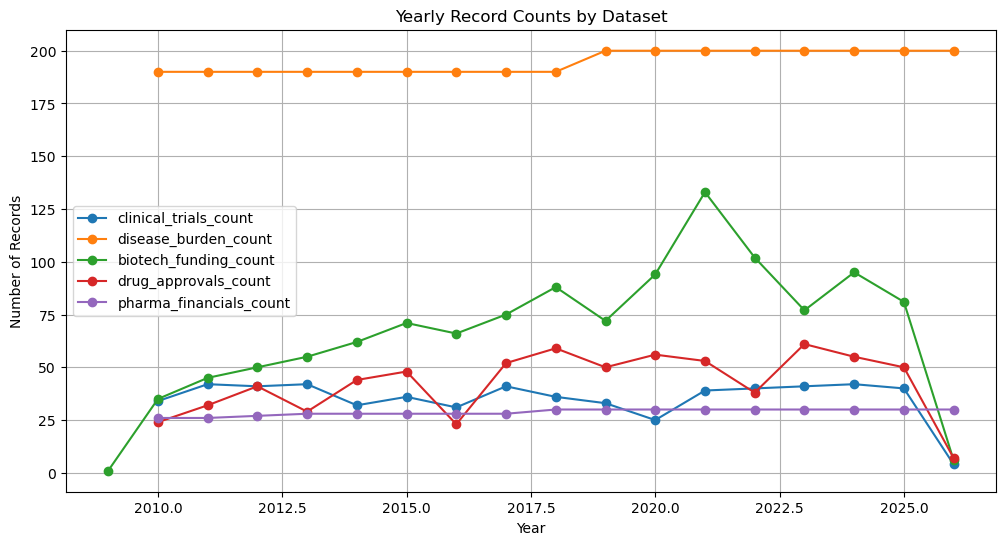

In [10]:
import matplotlib.pyplot as plt

yearly_record_counts.plot(
    x="year",
    y=[
        "clinical_trials_count",
        "disease_burden_count",
        "biotech_funding_count",
        "drug_approvals_count",
        "pharma_financials_count"
    ],
    figsize=(12, 6),
    marker="o"
)

plt.title("Yearly Record Counts by Dataset")
plt.xlabel("Year")
plt.ylabel("Number of Records")
plt.grid(True)
plt.show()

### Yearly Record Count Visualization Observation

The visualization confirms that disease burden and pharma financial records are relatively stable across years, while clinical trials, drug approvals, and biotech funding show more variation over time.

Biotech funding shows a clear peak around 2021, which may reflect the post-COVID investment environment and increased biotech market activity.

The sharp decline in 2026 should not be interpreted as a full-year trend because the dataset only covers a partial year for 2026.

## Step 30: Create Main Analysis Period Excluding Partial 2026

Since 2026 is a partial year in several datasets, this step creates filtered versions of the datasets for the main trend analysis period from 2010 to 2025.

In [11]:
clinical_trials_main = clinical_trials[(clinical_trials["year"] >= 2010) & (clinical_trials["year"] <= 2025)]
disease_burden_main = disease_burden[(disease_burden["year"] >= 2010) & (disease_burden["year"] <= 2025)]
biotech_funding_main = biotech_funding[(biotech_funding["year"] >= 2010) & (biotech_funding["year"] <= 2025)]
drug_approvals_main = drug_approvals[(drug_approvals["year"] >= 2010) & (drug_approvals["year"] <= 2025)]
pharma_financials_main = pharma_financials[(pharma_financials["year"] >= 2010) & (pharma_financials["year"] <= 2025)]

## Step 31: Validate Main Analysis Period Filters

This step checks the shape and year range of the filtered datasets created for the main 2010–2025 analysis period.

In [12]:
main_period_check = pd.DataFrame({
    "dataset": [
        "clinical_trials_main",
        "disease_burden_main",
        "biotech_funding_main",
        "drug_approvals_main",
        "pharma_financials_main"
    ],
    "rows": [
        clinical_trials_main.shape[0],
        disease_burden_main.shape[0],
        biotech_funding_main.shape[0],
        drug_approvals_main.shape[0],
        pharma_financials_main.shape[0]
    ],
    "columns": [
        clinical_trials_main.shape[1],
        disease_burden_main.shape[1],
        biotech_funding_main.shape[1],
        drug_approvals_main.shape[1],
        pharma_financials_main.shape[1]
    ],
    "min_year": [
        clinical_trials_main["year"].min(),
        disease_burden_main["year"].min(),
        biotech_funding_main["year"].min(),
        drug_approvals_main["year"].min(),
        pharma_financials_main["year"].min()
    ],
    "max_year": [
        clinical_trials_main["year"].max(),
        disease_burden_main["year"].max(),
        biotech_funding_main["year"].max(),
        drug_approvals_main["year"].max(),
        pharma_financials_main["year"].max()
    ]
})

main_period_check

,dataset,rows,columns,min_year,max_year
0,clinical_trials_main,595,12,2010,2025
1,disease_burden_main,3110,5,2010,2025
2,biotech_funding_main,1201,10,2010,2025
3,drug_approvals_main,715,12,2010,2025
4,pharma_financials_main,459,10,2010,2025


### Main Analysis Period Validation

The filtered datasets now cover the consistent 2010–2025 period.

This removes the partial-year effect from 2026 and excludes the single 2009 biotech funding record. These filtered datasets will be used for the main trend analysis, while the original datasets remain available for reference.

## Step 34: Preview Main Pharma Financials Dataset

This step previews the filtered pharma financials dataset for the 2010–2025 main analysis period. It helps confirm the available company-level financial columns before starting the financial performance analysis.

In [13]:
pharma_financials_main.head()

,year,company_name,ticker,country_iso3,segment,revenue_usd_bn,operating_margin_pct,operating_income_usd_bn,rd_spend_usd_bn,pipeline_size_est
0,2010,Johnson & Johnson,JNJ,USA,diversified_pharma,62.17,18.9,11.74,7.46,74
1,2011,Johnson & Johnson,JNJ,USA,diversified_pharma,64.74,24.8,16.07,7.77,75
2,2012,Johnson & Johnson,JNJ,USA,diversified_pharma,61.30,18.1,11.09,7.36,74
3,2013,Johnson & Johnson,JNJ,USA,diversified_pharma,66.96,21.1,14.10,8.03,76
4,2014,Johnson & Johnson,JNJ,USA,diversified_pharma,68.37,19.4,13.29,8.20,76


## Step 35: Calculate Total Revenue by Year

This step calculates total pharma company revenue by year for the 2010–2025 main analysis period. It provides a high-level view of how the combined revenue of covered companies changed over time.

In [14]:
revenue_by_year = (
    pharma_financials_main
    .groupby("year")["revenue_usd_bn"]
    .sum()
    .reset_index()
)

revenue_by_year

,year,revenue_usd_bn
0,2010,640.24
1,2011,643.01
2,2012,643.09
3,2013,662.43
4,2014,674.78
5,2015,688.35
6,2016,716.36
7,2017,732.36
8,2018,753.19
9,2019,785.16


## Step 36: Visualize Total Revenue by Year

This step visualizes the total annual revenue of the covered pharma companies during the 2010–2025 main analysis period. The chart helps identify long-term revenue growth, major jumps, and possible market-cycle effects.

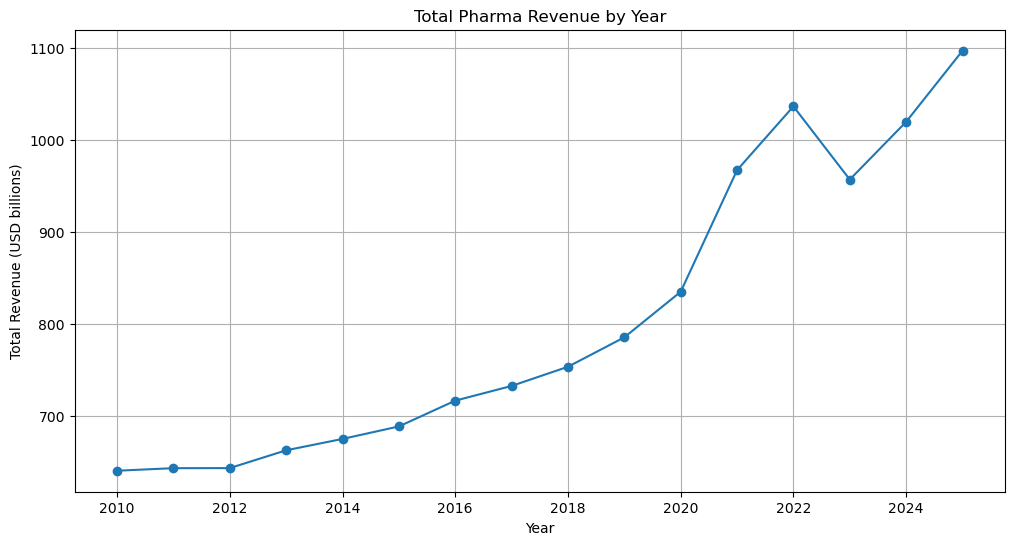

In [15]:
plt.figure(figsize=(12, 6))

plt.plot(
    revenue_by_year["year"],
    revenue_by_year["revenue_usd_bn"],
    marker="o"
)

plt.title("Total Pharma Revenue by Year")
plt.xlabel("Year")
plt.ylabel("Total Revenue (USD billions)")
plt.grid(True)
plt.show()

### Total Revenue Trend Observation

Total revenue across the covered pharma companies increased strongly between 2010 and 2025.

The trend shows gradual growth from 2010 to 2019, followed by a sharper increase after 2020. Revenue peaked in 2022, declined in 2023, and then recovered strongly in 2024 and 2025.

This pattern suggests that the post-2020 period may have been shaped by major market events such as pandemic-related pharmaceutical demand, vaccine revenues, and the later growth of high-value therapeutic areas such as GLP-1 drugs. Further company-level analysis is needed to identify which companies contributed most to this growth.

## Step 38: Calculate Total R&D Spending by Year

This step calculates total annual R&D spending across the covered pharma companies during the 2010–2025 main analysis period. It helps evaluate whether industry-level research investment increased alongside revenue growth.

In [16]:
rd_spend_by_year = (
    pharma_financials_main
    .groupby("year")["rd_spend_usd_bn"]
    .sum()
    .reset_index()
)

rd_spend_by_year

,year,rd_spend_usd_bn
0,2010,102.78
1,2011,103.49
2,2012,103.76
3,2013,107.49
4,2014,109.63
5,2015,111.98
6,2016,116.69
7,2017,118.88
8,2018,122.46
9,2019,128.23


## Step 39: Visualize Total R&D Spending by Year

This step visualizes total annual R&D spending across the covered pharma companies during the 2010–2025 main analysis period. The chart helps compare the growth pattern of research investment over time.

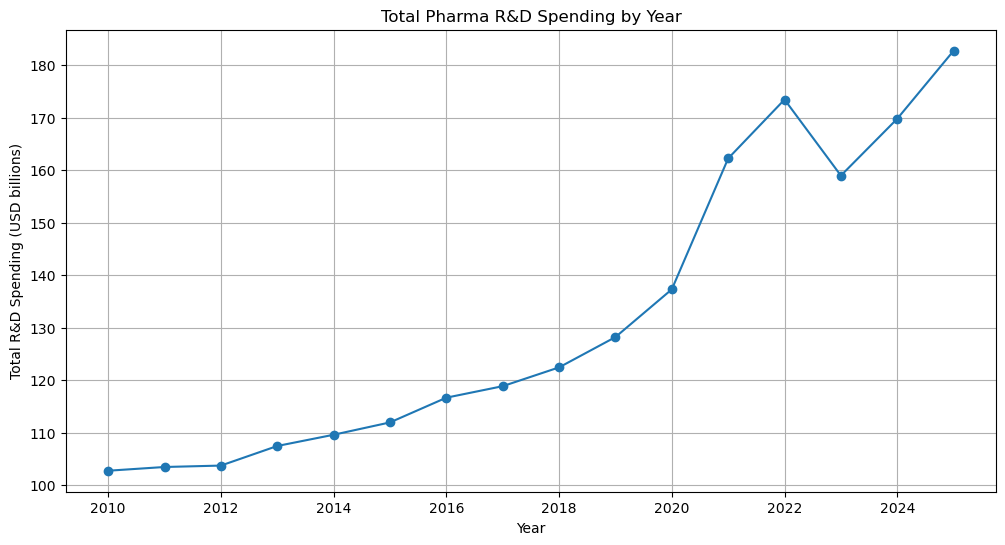

In [17]:
plt.figure(figsize=(12, 6))

plt.plot(
    rd_spend_by_year["year"],
    rd_spend_by_year["rd_spend_usd_bn"],
    marker="o"
)

plt.title("Total Pharma R&D Spending by Year")
plt.xlabel("Year")
plt.ylabel("Total R&D Spending (USD billions)")
plt.grid(True)
plt.show()

### Total R&D Spending Trend Observation

Total R&D spending increased steadily between 2010 and 2025.

The trend shows gradual growth from 2010 to 2019, followed by a sharper increase after 2020. R&D spending peaked in 2022, declined in 2023, and reached a new high in 2025.

This pattern is broadly similar to the total revenue trend, suggesting that industry-level research investment may have expanded alongside revenue growth. Further analysis is needed to compare revenue and R&D spending directly and evaluate R&D intensity over time.

## Step 41: Combine Revenue and R&D Spending by Year

This step combines annual total revenue and annual total R&D spending into a single table. This allows direct comparison between industry revenue growth and research investment growth over time.

In [18]:
revenue_rd_by_year = revenue_by_year.merge(
    rd_spend_by_year,
    on="year",
    how="inner"
)

revenue_rd_by_year

,year,revenue_usd_bn,rd_spend_usd_bn
0,2010,640.24,102.78
1,2011,643.01,103.49
2,2012,643.09,103.76
3,2013,662.43,107.49
4,2014,674.78,109.63
5,2015,688.35,111.98
6,2016,716.36,116.69
7,2017,732.36,118.88
8,2018,753.19,122.46
9,2019,785.16,128.23


## Step 42: Calculate Industry-Level R&D Intensity

This step calculates R&D intensity at the industry level by dividing total R&D spending by total revenue for each year.

R&D Intensity = Total R&D Spending / Total Revenue

This metric helps evaluate how much of annual revenue is reinvested into research and development.

In [19]:
revenue_rd_by_year["rd_intensity_pct"] = (
    revenue_rd_by_year["rd_spend_usd_bn"] / revenue_rd_by_year["revenue_usd_bn"]
) * 100

revenue_rd_by_year

,year,revenue_usd_bn,rd_spend_usd_bn,rd_intensity_pct
0,2010,640.24,102.78,16.053355
1,2011,643.01,103.49,16.094618
2,2012,643.09,103.76,16.134600
3,2013,662.43,107.49,16.226620
4,2014,674.78,109.63,16.246777
5,2015,688.35,111.98,16.267887
6,2016,716.36,116.69,16.289296
7,2017,732.36,118.88,16.232454
8,2018,753.19,122.46,16.258846
9,2019,785.16,128.23,16.331703


## Step 43: Visualize Industry-Level R&D Intensity

This step visualizes annual R&D intensity across the covered pharma companies. It shows whether the share of revenue reinvested into R&D changed over time.

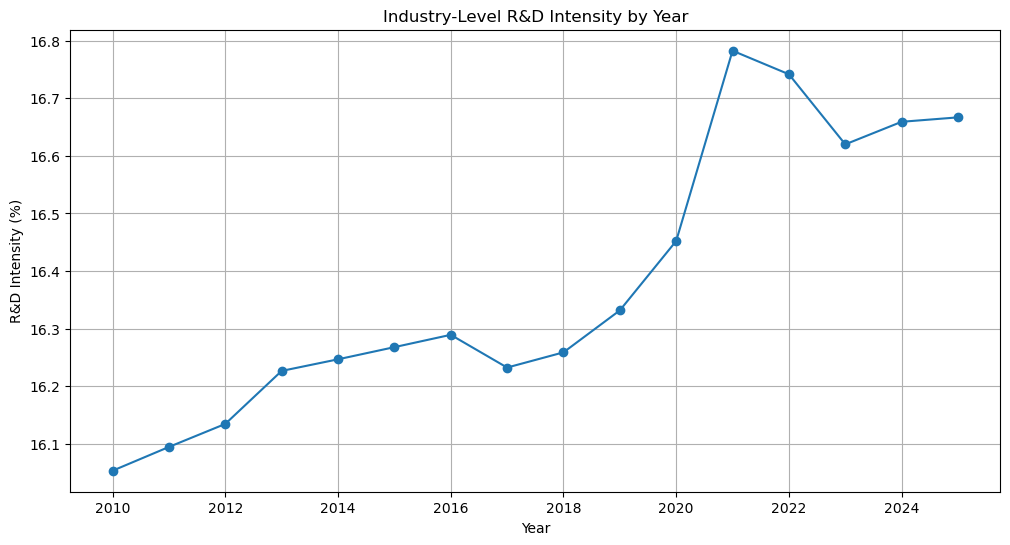

In [20]:
plt.figure(figsize=(12, 6))

plt.plot(
    revenue_rd_by_year["year"],
    revenue_rd_by_year["rd_intensity_pct"],
    marker="o"
)

plt.title("Industry-Level R&D Intensity by Year")
plt.xlabel("Year")
plt.ylabel("R&D Intensity (%)")
plt.grid(True)
plt.show()

### Industry-Level R&D Intensity Observation

Industry-level R&D intensity remained within a relatively narrow range between 2010 and 2025, increasing from approximately 16.1% in 2010 to approximately 16.7% in 2025.

Although total R&D spending increased substantially over time, R&D intensity changed more moderately. This suggests that research investment grew largely alongside revenue rather than dramatically outpacing it.

The strongest increase appears after 2020, with R&D intensity reaching its highest level around 2021–2022 before stabilizing slightly lower in later years.

## Step 45: Calculate Revenue and R&D Growth from 2010 to 2025

This step calculates total growth in revenue and R&D spending between 2010 and 2025. It helps compare whether research investment grew faster or slower than total revenue over the main analysis period.

In [21]:
start_year = 2010
end_year = 2025

revenue_start = revenue_rd_by_year.loc[
    revenue_rd_by_year["year"] == start_year, 
    "revenue_usd_bn"
].iloc[0]

revenue_end = revenue_rd_by_year.loc[
    revenue_rd_by_year["year"] == end_year, 
    "revenue_usd_bn"
].iloc[0]

rd_start = revenue_rd_by_year.loc[
    revenue_rd_by_year["year"] == start_year, 
    "rd_spend_usd_bn"
].iloc[0]

rd_end = revenue_rd_by_year.loc[
    revenue_rd_by_year["year"] == end_year, 
    "rd_spend_usd_bn"
].iloc[0]

revenue_growth_pct = ((revenue_end - revenue_start) / revenue_start) * 100
rd_growth_pct = ((rd_end - rd_start) / rd_start) * 100

growth_summary = pd.DataFrame({
    "metric": ["Total Revenue", "Total R&D Spending"],
    "start_2010_usd_bn": [revenue_start, rd_start],
    "end_2025_usd_bn": [revenue_end, rd_end],
    "growth_pct": [revenue_growth_pct, rd_growth_pct]
})

growth_summary

,metric,start_2010_usd_bn,end_2025_usd_bn,growth_pct
0,Total Revenue,640.24,1096.55,71.271711
1,Total R&D Spending,102.78,182.76,77.816696


### Revenue vs R&D Growth Observation

Between 2010 and 2025, total revenue across the covered pharma companies increased by approximately 71.3%, while total R&D spending increased by approximately 77.8%.

This indicates that R&D spending grew slightly faster than revenue over the main analysis period. However, the difference is moderate, which aligns with the earlier R&D intensity trend showing a relatively stable but gradually increasing R&D share of revenue.

## Step 47: Rank Companies by Revenue in 2025

This step ranks companies by revenue in 2025. It helps identify the largest commercial performers at the end of the main analysis period.

In [22]:
revenue_2025 = (
    pharma_financials_main[pharma_financials_main["year"] == 2025]
    .sort_values("revenue_usd_bn", ascending=False)
    [["company_name", "ticker", "segment", "revenue_usd_bn"]]
    .reset_index(drop=True)
)

revenue_2025.head(10)

,company_name,ticker,segment,revenue_usd_bn
0,Johnson & Johnson,JNJ,diversified_pharma,98.00
1,Merck,MRK,big_pharma,69.00
2,Roche,ROG,big_pharma,68.31
3,Pfizer,PFE,big_pharma,65.69
4,Eli Lilly,LLY,big_pharma,59.78
5,AstraZeneca,AZN,big_pharma,58.57
6,AbbVie,ABBV,big_pharma,56.25
7,Novartis,NVS,big_pharma,53.15
8,Bristol-Myers Squibb,BMY,big_pharma,51.43
9,Novo Nordisk,NVO,big_pharma,49.33


## Step 48: Visualize Top 10 Companies by Revenue in 2025

This step visualizes the top 10 companies by revenue in 2025. The chart highlights the largest commercial performers at the end of the main analysis period.

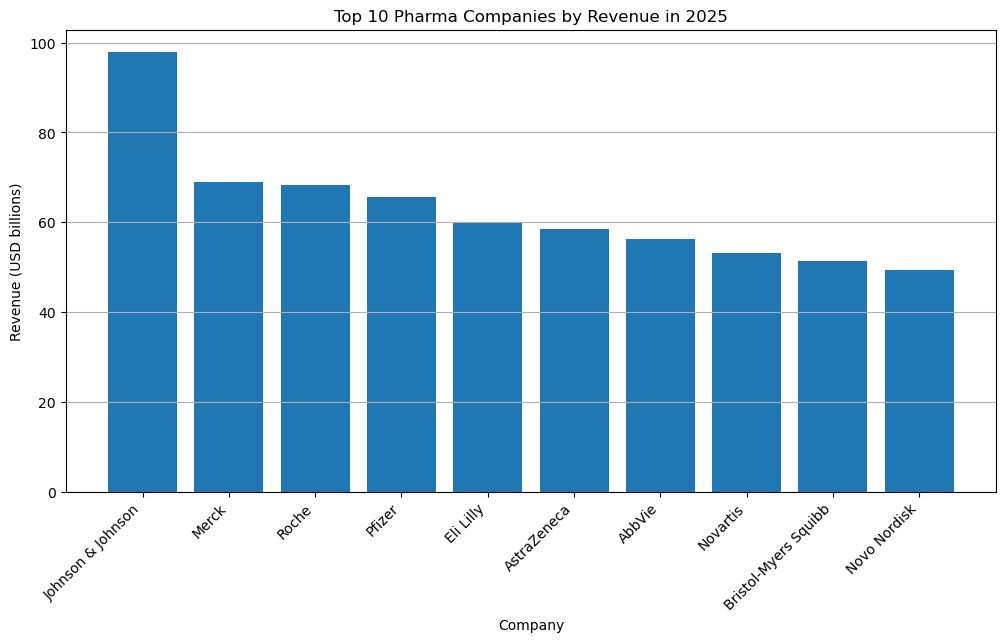

In [23]:
top10_revenue_2025 = revenue_2025.head(10)

plt.figure(figsize=(12, 6))

plt.bar(
    top10_revenue_2025["company_name"],
    top10_revenue_2025["revenue_usd_bn"]
)

plt.title("Top 10 Pharma Companies by Revenue in 2025")
plt.xlabel("Company")
plt.ylabel("Revenue (USD billions)")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")
plt.show()

### Top 10 Revenue Companies Observation

In 2025, Johnson & Johnson had the highest revenue among the covered companies, reaching approximately 98B USD.

The next group of large revenue performers includes Merck, Roche, Pfizer, Eli Lilly, AstraZeneca, AbbVie, Novartis, Bristol-Myers Squibb, and Novo Nordisk.

The ranking shows that large diversified and big pharma companies continue to dominate the commercial landscape. However, the presence of Eli Lilly and Novo Nordisk among the top 10 also suggests the growing importance of high-value therapeutic areas such as obesity and diabetes.

## Step 50: Calculate Company Revenue Growth from 2010 to 2025

This step calculates revenue growth for each company between 2010 and 2025. It helps identify which companies experienced the strongest commercial growth during the main analysis period.

In [24]:
company_revenue_2010 = (
    pharma_financials_main[pharma_financials_main["year"] == 2010]
    [["company_name", "ticker", "segment", "revenue_usd_bn"]]
    .rename(columns={"revenue_usd_bn": "revenue_2010_usd_bn"})
)

company_revenue_2025 = (
    pharma_financials_main[pharma_financials_main["year"] == 2025]
    [["company_name", "ticker", "segment", "revenue_usd_bn"]]
    .rename(columns={"revenue_usd_bn": "revenue_2025_usd_bn"})
)

company_revenue_growth = (
    company_revenue_2010
    .merge(
        company_revenue_2025,
        on=["company_name", "ticker", "segment"],
        how="inner"
    )
)

company_revenue_growth["revenue_growth_usd_bn"] = (
    company_revenue_growth["revenue_2025_usd_bn"] - company_revenue_growth["revenue_2010_usd_bn"]
)

company_revenue_growth["revenue_growth_pct"] = (
    company_revenue_growth["revenue_growth_usd_bn"] / company_revenue_growth["revenue_2010_usd_bn"]
) * 100

company_revenue_growth = company_revenue_growth.sort_values(
    "revenue_growth_pct",
    ascending=False
).reset_index(drop=True)

company_revenue_growth.head(10)

,company_name,ticker,segment,revenue_2010_usd_bn,revenue_2025_usd_bn,revenue_growth_usd_bn,revenue_growth_pct
0,Regeneron,REGN,biotech,0.48,14.92,14.44,3008.333333
1,Hengrui Medicine,600276,big_pharma,0.55,4.11,3.56,647.272727
2,Sun Pharma,SUNPHARMA,generics,1.55,7.69,6.14,396.129032
3,Novo Nordisk,NVO,big_pharma,11.77,49.33,37.56,319.116398
4,Gilead Sciences,GILD,biotech,7.35,30.35,23.00,312.925170
5,Stryker,SYK,medical_devices,7.14,24.45,17.31,242.436975
6,Eli Lilly,LLY,big_pharma,23.12,59.78,36.66,158.564014
7,Bristol-Myers Squibb,BMY,big_pharma,20.54,51.43,30.89,150.389484
8,Amgen,AMGN,biotech,13.82,34.06,20.24,146.454414
9,Biogen,BIIB,biotech,4.60,9.79,5.19,112.826087


### Company Revenue Growth Observation

The company-level growth ranking shows that the fastest-growing companies by percentage are not necessarily the largest companies by absolute revenue.

Regeneron shows the highest percentage growth between 2010 and 2025, but this is partly influenced by its very low revenue base in 2010. Novo Nordisk and Eli Lilly also show strong growth, with much larger absolute revenue gains, making them especially important for later case study analysis.

This suggests that both percentage growth and absolute revenue growth should be considered together when evaluating company performance.

## Step 52: Rank Companies by Absolute Revenue Growth

This step ranks companies by absolute revenue growth between 2010 and 2025. This helps identify which companies added the largest amount of revenue in USD terms, regardless of their starting size.

In [25]:
company_revenue_growth_absolute = (
    company_revenue_growth
    .sort_values("revenue_growth_usd_bn", ascending=False)
    .reset_index(drop=True)
)

company_revenue_growth_absolute.head(10)

,company_name,ticker,segment,revenue_2010_usd_bn,revenue_2025_usd_bn,revenue_growth_usd_bn,revenue_growth_pct
0,Novo Nordisk,NVO,big_pharma,11.77,49.33,37.56,319.116398
1,Eli Lilly,LLY,big_pharma,23.12,59.78,36.66,158.564014
2,Johnson & Johnson,JNJ,diversified_pharma,62.17,98.00,35.83,57.632299
3,Bristol-Myers Squibb,BMY,big_pharma,20.54,51.43,30.89,150.389484
4,AstraZeneca,AZN,big_pharma,33.46,58.57,25.11,75.044830
5,Gilead Sciences,GILD,biotech,7.35,30.35,23.00,312.925170
6,Merck,MRK,big_pharma,46.33,69.00,22.67,48.931578
7,Amgen,AMGN,biotech,13.82,34.06,20.24,146.454414
8,Medtronic,MDT,medical_devices,16.65,34.44,17.79,106.846847
9,Stryker,SYK,medical_devices,7.14,24.45,17.31,242.436975


### Absolute Revenue Growth Observation

When companies are ranked by absolute revenue growth, Novo Nordisk and Eli Lilly emerge as the strongest performers between 2010 and 2025.

Both companies added more than 36B USD in annual revenue over the period, making them important candidates for a later GLP-1-focused case study.

Johnson & Johnson also added substantial revenue, but from a much larger starting base. This comparison shows why absolute growth and percentage growth should be interpreted together.

## Step 54: Visualize Top 10 Companies by Absolute Revenue Growth

This step visualizes the top 10 companies by absolute revenue growth between 2010 and 2025. The chart highlights which companies added the largest amount of annual revenue over the main analysis period.

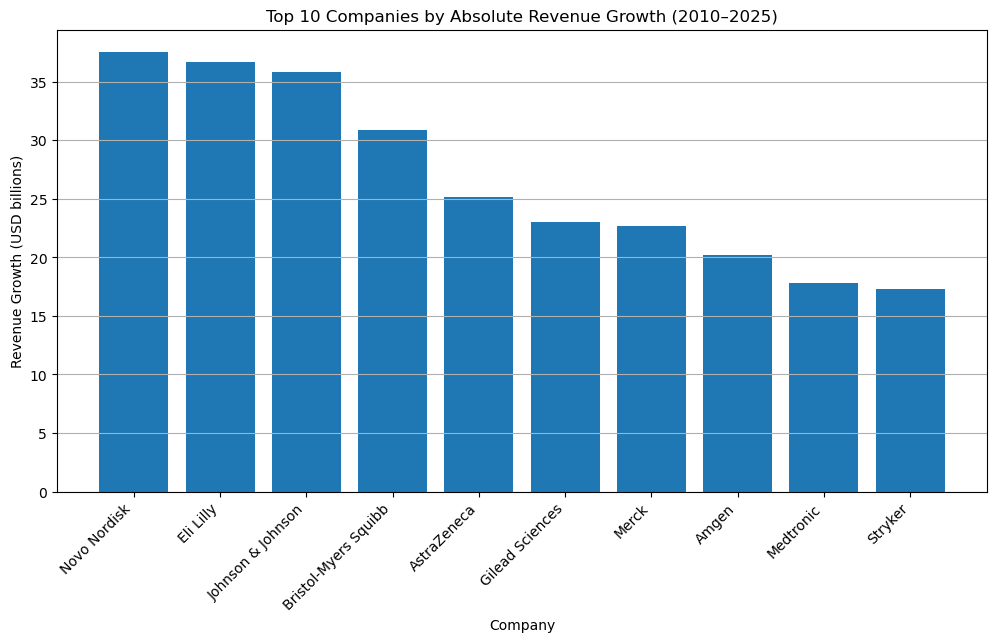

In [26]:
top10_absolute_growth = company_revenue_growth_absolute.head(10)

plt.figure(figsize=(12, 6))

plt.bar(
    top10_absolute_growth["company_name"],
    top10_absolute_growth["revenue_growth_usd_bn"]
)

plt.title("Top 10 Companies by Absolute Revenue Growth (2010–2025)")
plt.xlabel("Company")
plt.ylabel("Revenue Growth (USD billions)")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")
plt.show()

### Absolute Revenue Growth Visualization Observation

The absolute revenue growth chart shows that Novo Nordisk and Eli Lilly added the largest amount of annual revenue between 2010 and 2025.

This supports the idea that these companies were not only large in 2025, but also among the strongest commercial growth stories over the full analysis period.

Johnson & Johnson also shows strong absolute growth, although it started from a much larger revenue base. This reinforces the need to evaluate company performance using both growth percentage and absolute revenue expansion.

## Step 56: Rank Companies by R&D Spending in 2025

This step ranks companies by R&D spending in 2025. It helps identify which companies invested the most in research and development at the end of the main analysis period.

In [27]:
rd_spend_2025 = (
    pharma_financials_main[pharma_financials_main["year"] == 2025]
    .sort_values("rd_spend_usd_bn", ascending=False)
    [["company_name", "ticker", "segment", "rd_spend_usd_bn", "revenue_usd_bn"]]
    .reset_index(drop=True)
)

rd_spend_2025.head(10)

,company_name,ticker,segment,rd_spend_usd_bn,revenue_usd_bn
0,Merck,MRK,big_pharma,12.42,69.00
1,Roche,ROG,big_pharma,12.30,68.31
2,Pfizer,PFE,big_pharma,11.82,65.69
3,Johnson & Johnson,JNJ,diversified_pharma,11.76,98.00
4,Eli Lilly,LLY,big_pharma,10.76,59.78
5,AstraZeneca,AZN,big_pharma,10.54,58.57
6,AbbVie,ABBV,big_pharma,10.13,56.25
7,Novartis,NVS,big_pharma,9.57,53.15
8,Bristol-Myers Squibb,BMY,big_pharma,9.26,51.43
9,Novo Nordisk,NVO,big_pharma,8.88,49.33


## Step 57: Visualize Top 10 Companies by R&D Spending in 2025

This step visualizes the top 10 companies by R&D spending in 2025. The chart highlights which companies invested the largest absolute amount in research and development.

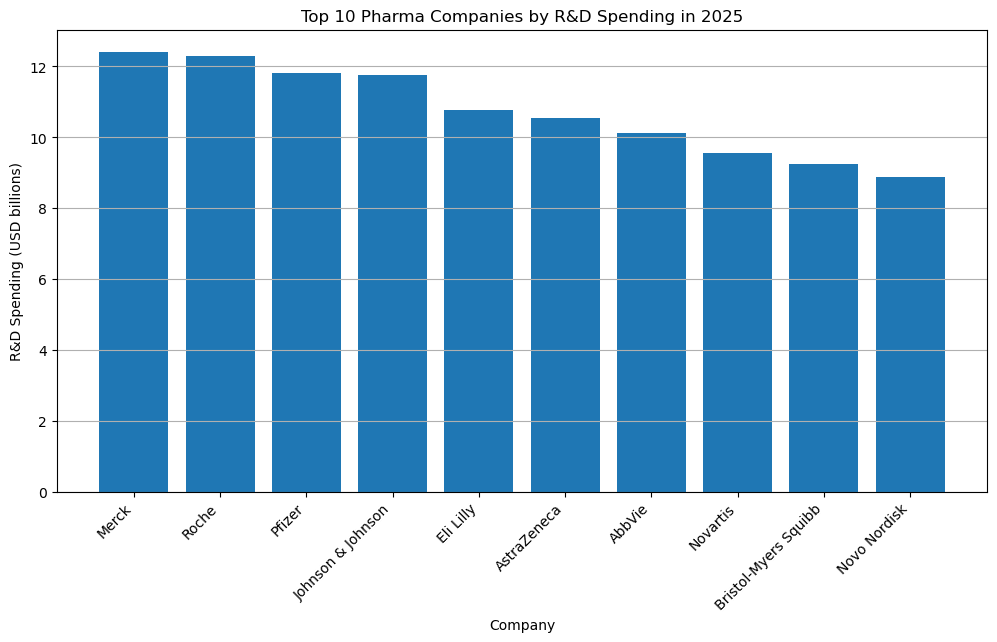

In [28]:
top10_rd_spend_2025 = rd_spend_2025.head(10)

plt.figure(figsize=(12, 6))

plt.bar(
    top10_rd_spend_2025["company_name"],
    top10_rd_spend_2025["rd_spend_usd_bn"]
)

plt.title("Top 10 Pharma Companies by R&D Spending in 2025")
plt.xlabel("Company")
plt.ylabel("R&D Spending (USD billions)")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")
plt.show()

### Top 10 R&D Spending Companies Observation

In 2025, Merck and Roche had the highest absolute R&D spending among the covered companies, followed by Pfizer and Johnson & Johnson.

The ranking shows that the largest revenue companies are not always the highest R&D spenders. Johnson & Johnson ranked first by revenue in 2025 but ranked fourth by R&D spending.

Novo Nordisk was one of the strongest companies by absolute revenue growth, but ranked lower in absolute R&D spending compared with several larger big pharma companies. This suggests that absolute R&D spending should be complemented with R&D intensity analysis.

## Step 59: Calculate Company-Level R&D Intensity in 2025

This step calculates R&D intensity for each company in 2025.

R&D Intensity = R&D Spending / Revenue

This metric helps compare research investment relative to company size, rather than only comparing absolute R&D spending.

In [29]:
rd_intensity_2025 = pharma_financials_main[
    pharma_financials_main["year"] == 2025
].copy()

rd_intensity_2025["rd_intensity_pct"] = (
    rd_intensity_2025["rd_spend_usd_bn"] / rd_intensity_2025["revenue_usd_bn"]
) * 100

rd_intensity_2025 = (
    rd_intensity_2025
    .sort_values("rd_intensity_pct", ascending=False)
    [["company_name", "ticker", "segment", "revenue_usd_bn", "rd_spend_usd_bn", "rd_intensity_pct"]]
    .reset_index(drop=True)
)

rd_intensity_2025.head(10)

,company_name,ticker,segment,revenue_usd_bn,rd_spend_usd_bn,rd_intensity_pct
0,Biogen,BIIB,biotech,9.79,2.45,25.025536
1,Amgen,AMGN,biotech,34.06,8.52,25.014680
2,Gilead Sciences,GILD,biotech,30.35,7.59,25.008237
3,BioNTech,BNTX,biotech,3.40,0.85,25.000000
4,Moderna,MRNA,biotech,4.44,1.11,25.000000
5,Regeneron,REGN,biotech,14.92,3.73,25.000000
6,Vertex Pharmaceuticals,VRTX,biotech,12.34,3.08,24.959481
7,AbbVie,ABBV,big_pharma,56.25,10.13,18.008889
8,Sanofi,SAN,big_pharma,41.43,7.46,18.006276
9,Roche,ROG,big_pharma,68.31,12.30,18.006148


## Step 60: Visualize Top 10 Companies by R&D Intensity in 2025

This step visualizes the top 10 companies by R&D intensity in 2025. The chart highlights which companies invested the highest share of revenue into research and development.

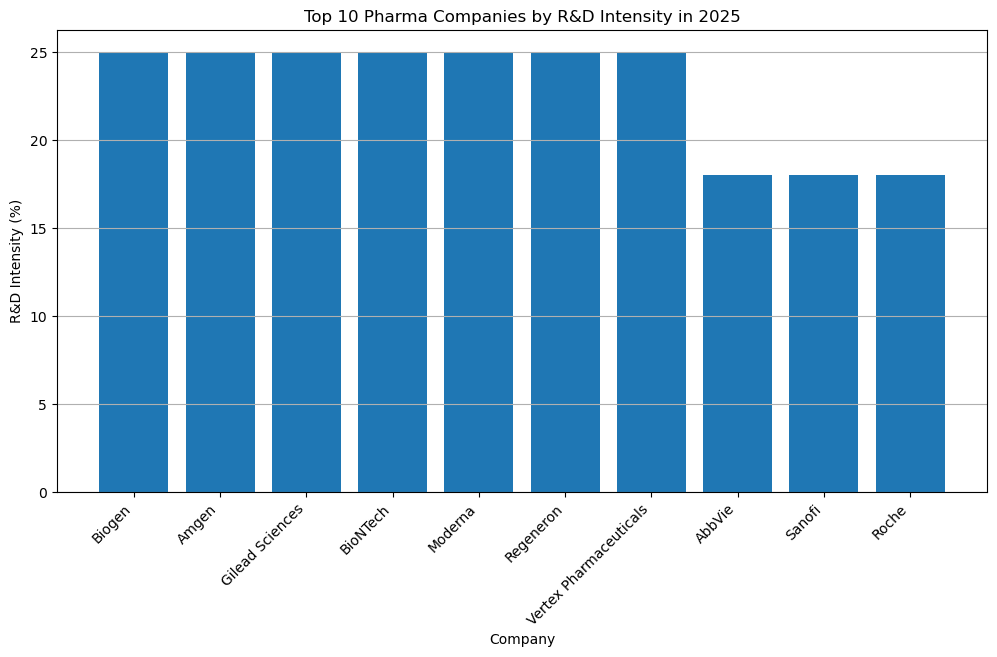

In [30]:
top10_rd_intensity_2025 = rd_intensity_2025.head(10)

plt.figure(figsize=(12, 6))

plt.bar(
    top10_rd_intensity_2025["company_name"],
    top10_rd_intensity_2025["rd_intensity_pct"]
)

plt.title("Top 10 Pharma Companies by R&D Intensity in 2025")
plt.xlabel("Company")
plt.ylabel("R&D Intensity (%)")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")
plt.show()

### Company-Level R&D Intensity Observation

The 2025 R&D intensity ranking shows a clear segment difference.

Biotech companies dominate the top positions, with several firms investing around 25% of their revenue into R&D. In contrast, the highest-ranked big pharma companies in this view are closer to 18%.

This suggests that biotech companies may be more research-intensive relative to their revenue base, while larger big pharma companies dominate in absolute R&D spending.

## Step 62: Calculate Average R&D Intensity by Segment in 2025

This step calculates the average R&D intensity by company segment in 2025. It helps evaluate whether biotech, big pharma, generics, medical devices, or diversified pharma companies differ in their research investment intensity.

In [31]:
segment_rd_intensity_2025 = (
    rd_intensity_2025
    .groupby("segment")
    .agg(
        company_count=("company_name", "nunique"),
        avg_revenue_usd_bn=("revenue_usd_bn", "mean"),
        avg_rd_spend_usd_bn=("rd_spend_usd_bn", "mean"),
        avg_rd_intensity_pct=("rd_intensity_pct", "mean")
    )
    .sort_values("avg_rd_intensity_pct", ascending=False)
    .reset_index()
)

segment_rd_intensity_2025

,segment,company_count,avg_revenue_usd_bn,avg_rd_spend_usd_bn,avg_rd_intensity_pct
0,biotech,7,15.614286,3.904286,25.001134
1,big_pharma,15,45.918000,8.265333,17.999033
2,diversified_pharma,3,63.090000,7.570000,11.998401
3,diagnostics,1,25.230000,2.520000,9.988109
4,medical_devices,2,29.445000,2.360000,8.015149
5,generics,2,12.545000,0.750000,5.979403


### Segment-Level R&D Intensity Observation

The segment-level comparison confirms that biotech companies had the highest average R&D intensity in 2025, at approximately 25% of revenue.

Big pharma companies ranked second, with an average R&D intensity of approximately 18%. Other segments, including diversified pharma, diagnostics, medical devices, and generics, showed lower R&D intensity.

This suggests that biotech companies are more research-intensive relative to their revenue base, while big pharma companies combine larger revenue scale with substantial but proportionally lower R&D investment.

## Step 64: Visualize Average R&D Intensity by Segment in 2025

This step visualizes average R&D intensity by company segment in 2025. The chart highlights differences in research investment intensity across business models.

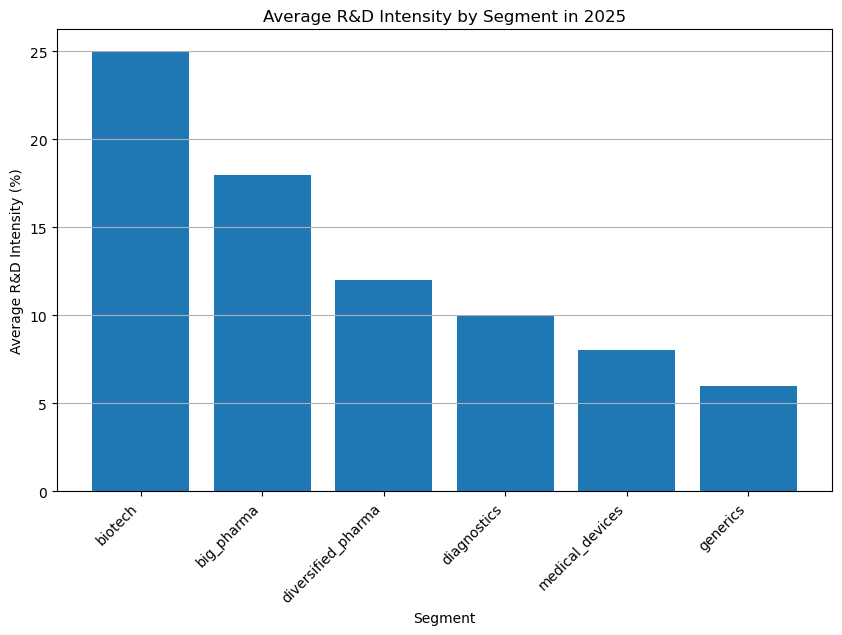

In [32]:
plt.figure(figsize=(10, 6))

plt.bar(
    segment_rd_intensity_2025["segment"],
    segment_rd_intensity_2025["avg_rd_intensity_pct"]
)

plt.title("Average R&D Intensity by Segment in 2025")
plt.xlabel("Segment")
plt.ylabel("Average R&D Intensity (%)")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")
plt.show()

### Segment R&D Intensity Visualization Observation

The segment-level visualization shows a clear difference in R&D intensity across business models.

Biotech companies had the highest average R&D intensity in 2025, followed by big pharma. Generics, medical devices, and diagnostics showed lower average R&D intensity.

This supports the idea that biotech companies are more research-intensive relative to revenue, while other segments may rely more on scale, manufacturing, device portfolios, diagnostics, or established product lines.

## Company Financial Performance Interim Summary

The company financial analysis shows several important patterns:

- Total revenue across the covered companies increased substantially between 2010 and 2025.
- Total R&D spending also increased and grew slightly faster than total revenue.
- Industry-level R&D intensity remained relatively stable, moving within a narrow 16–17% range.
- Johnson & Johnson was the largest company by revenue in 2025.
- Novo Nordisk and Eli Lilly showed the strongest absolute revenue growth between 2010 and 2025.
- Merck and Roche led in absolute R&D spending in 2025.
- Biotech companies showed the highest R&D intensity relative to revenue, while big pharma companies dominated in absolute R&D spending.

These findings suggest that commercial scale and research intensity should be evaluated separately. Large pharma companies often dominate by absolute revenue and R&D spending, while biotech companies appear more research-intensive relative to their revenue base.

# Drug Approvals Analysis

This section explores drug approvals between 2010 and 2025. The analysis focuses on approval trends, therapy areas, drug types, sponsor companies, estimated peak sales, blockbuster potential, and the share of verified headline approvals.

## Step 67: Preview Main Drug Approvals Dataset

This step previews the filtered drug approvals dataset for the 2010–2025 main analysis period. It helps confirm the available approval-level columns before analyzing approval trends and blockbuster potential.

In [33]:
drug_approvals_main.head()

,approval_id,approval_date,year,drug_name,sponsor_company,drug_type,therapy_area,peak_sales_usd_bn_est,is_blockbuster,is_mega_blockbuster,description,is_real_headline
0,APP0062,2010-01-27,2010,Zolile-pril,Ionis,small_mol,neurology,2.09,1,0,FDA approval — neurology small_mol,0
1,APP0056,2010-02-13,2010,Ilemyr-zumab,Acadia,small_mol,neurology,0.28,0,0,FDA approval — neurology small_mol,0
2,APP0047,2010-03-09,2010,Lircor-tide,BioMarin,small_mol,gastrointestinal,0.42,0,0,FDA approval — gastrointestinal small_mol,0
3,APP0063,2010-03-12,2010,Urbxan-tinib,GSK,biologic,oncology,0.02,0,0,FDA approval — oncology biologic,0
4,APP0049,2010-04-04,2010,Ravxan-tide,Mirum,biologic,oncology,0.44,0,0,FDA approval — oncology biologic,0


## Step 68: Calculate Drug Approvals by Year

This step calculates the number of drug approvals by year during the 2010–2025 main analysis period. It helps identify whether approval activity increased, decreased, or fluctuated over time.

In [34]:
approvals_by_year = (
    drug_approvals_main
    .groupby("year")
    .size()
    .reset_index(name="approval_count")
)

approvals_by_year

,year,approval_count
0,2010,24
1,2011,32
2,2012,41
3,2013,29
4,2014,44
5,2015,48
6,2016,23
7,2017,52
8,2018,59
9,2019,50


## Step 69: Visualize Drug Approvals by Year

This step visualizes the number of drug approvals by year during the 2010–2025 main analysis period. The chart helps identify fluctuations, peak years, and longer-term approval activity patterns.

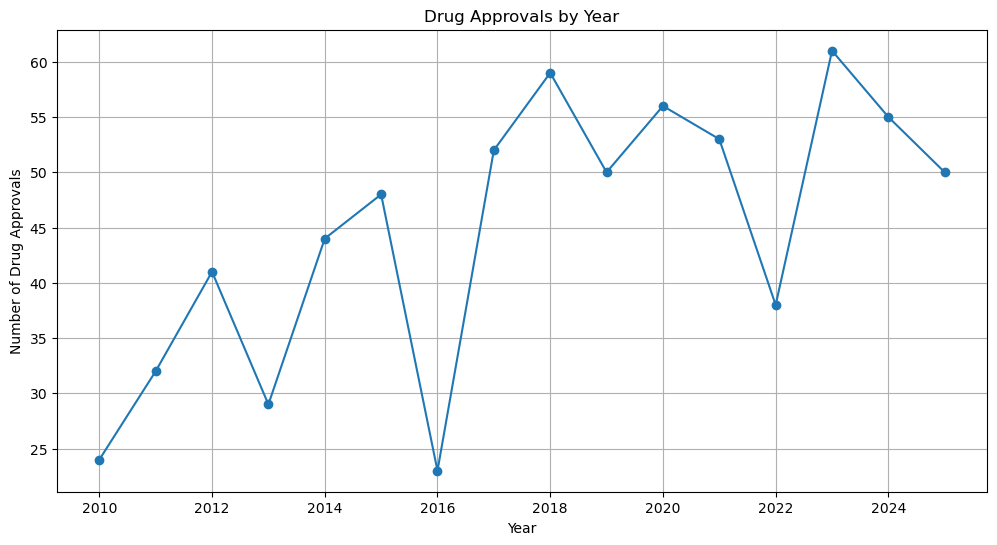

In [35]:
plt.figure(figsize=(12, 6))

plt.plot(
    approvals_by_year["year"],
    approvals_by_year["approval_count"],
    marker="o"
)

plt.title("Drug Approvals by Year")
plt.xlabel("Year")
plt.ylabel("Number of Drug Approvals")
plt.grid(True)
plt.show()

# Notebook Summary and Next Steps

This notebook completed the first part of the exploratory data analysis for the Global Healthcare & Pharma Analytics project.

Completed analysis areas:

- Initial summary statistics across all datasets
- Time coverage validation across datasets
- Main analysis period definition for 2010–2025
- Yearly record count analysis
- Company financial performance analysis
- Total revenue trend analysis
- Total R&D spending trend analysis
- Industry-level R&D intensity analysis
- Company-level revenue ranking
- Company-level revenue growth analysis
- Company-level R&D spending analysis
- Company and segment-level R&D intensity analysis

Key early insights:

- Total revenue and total R&D spending increased substantially between 2010 and 2025.
- R&D spending grew slightly faster than total revenue.
- Industry-level R&D intensity remained relatively stable within a narrow 16–17% range.
- Johnson & Johnson was the largest company by revenue in 2025.
- Novo Nordisk and Eli Lilly showed the strongest absolute revenue growth between 2010 and 2025.
- Merck and Roche led in absolute R&D spending in 2025.
- Biotech companies had the highest R&D intensity relative to revenue, while big pharma companies dominated in absolute R&D spending.

The next notebook will continue the exploratory analysis with a deeper focus on drug approvals and clinical trials.